In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML


Global variables

In [15]:
dimension = 256 #size of matrix
background_num = 30 #No. of background objects 
frames_num = 90    # number of animation frames 


Object & background 

In [16]:
# Fixed background
random_num = np.random.default_rng(1)
bg_positions = random_num.integers(0, dimension, size=(background_num, 2))

# Object matrix
def make_object(t):
    '''creates an object that moves in a figure 8 relative to a fixed background'''
    Obj = np.zeros((dimension, dimension))

    # Static background dots
    for y, x in bg_positions:
        Obj[y, x] = 1

    centre_x = dimension // 2
    centre_y = dimension // 2
    amp_x = 60
    amp_y = 60  

    x_move = int(centre_x + amp_x * np.sin(t))
    y_move = int(centre_y + amp_y * np.sin(2 * t))


    Obj[y_move, x_move] = 1

    # Convert to Gaussian dots 
    Obj = gaussian_filter(Obj, sigma=2)

    return Obj



Animation

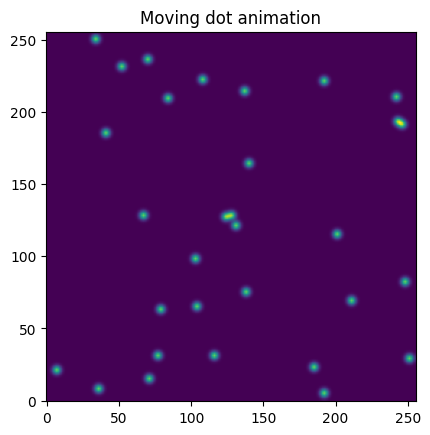

In [17]:
# animation
fig, ax = plt.subplots()
img = ax.imshow(make_object(0), origin='lower')
ax.set_title("Moving dot animation")

def animation_make_object(frame):
    '''inputs value for t to make each image frame'''
    t = 2 * np.pi * frame / frames_num
    img.set_data(make_object(t))
    return [img]

animation = FuncAnimation(fig, animation_make_object, frames=frames_num, interval=80)

HTML(animation.to_jshtml())

# Save object video
gif_writer = PillowWriter(fps=15)
animation.save("moving_object.gif", writer=gif_writer)

Random Speckle Pattern

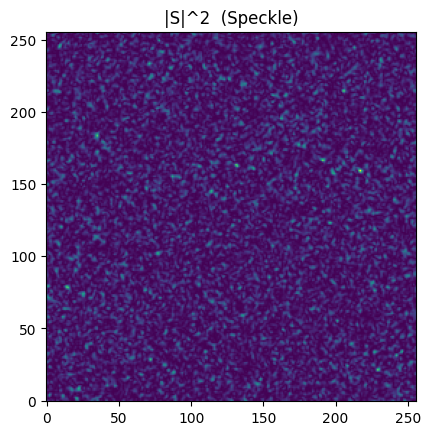

In [18]:
# Coordinate grid, 0 centred 
Y, X = np.indices((dimension, dimension))
X = X - dimension//2
Y = Y - dimension//2

#gaussian envelope
sigma_env = 40 #standard deviation 
gaussian_env = np.exp(-(X**2 + Y**2) / (2 * sigma_env**2))

# Random complex matrix
rand_complex = (
    np.random.uniform(-1, 1, (dimension, dimension)) + 1j * np.random.uniform(-1, 1, (dimension, dimension))
)

# field at barrier
field = rand_complex * gaussian_env


# speckle pattern - random
speckle_rand = np.fft.fftshift(np.fft.fft2(field)) # fast fourier transform, shift to centre
intensity_rand = np.abs(speckle_rand)**2

plt.imshow(intensity_rand, origin='lower')
plt.title("|S|^2  (Speckle)")
plt.show()

Tracking Object

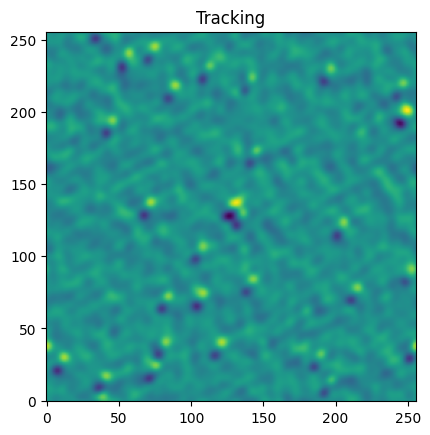

In [19]:
prev_image_clean = None
fft_speckle = np.fft.fft2(intensity_rand)
def track_object(frame):
    '''convolve object and speckle, track object using correlation I(t) ⋆ I(t-1) - I(t) ⋆ I(t)'''
    
    global prev_image_clean
    global fft_speckle
    t = 2 * np.pi * frame / frames_num
    Obj = make_object(t)

    # Convolution of speckle and object
    image = np.fft.ifft2(np.fft.fft2(Obj) * fft_speckle)
    image = np.real(image)

    # Remove background
    image_clean = image - np.mean(image)

    # for first frame
    if prev_image_clean is None:
        prev_image_clean = image_clean
        img.set_data(image_clean)
        img.set_clim(vmin=image_clean.min(), vmax=image_clean.max())
        return [img]

    # correlation - I(t) ⋆ I(t-1)
    correlation_shift = np.fft.ifft2(np.fft.fft2(image_clean) * np.conj(np.fft.fft2(prev_image_clean)))

    # correlation - I(t) ⋆ I(t)
    correlation_auto = np.fft.ifft2(np.fft.fft2(image_clean) * np.conj(np.fft.fft2(image_clean)))

    result = np.real(correlation_shift - correlation_auto)
    result = np.fft.fftshift(result)
    result=np.real(result)
    # Z-score normalization https://www.geeksforgeeks.org/data-analysis/z-score-normalization-definition-and-examples/
    result -= np.mean(result)
    
    img.set_data(result)
    img.set_clim(vmin=result.min(), vmax=result.max())
    
    prev_image_clean = image_clean

    return [img]

fig, ax = plt.subplots()
img = ax.imshow(np.zeros_like(intensity_rand), cmap='viridis', animated=True,origin='lower')
ax.set_title("Tracking")

#create animation
animation_tracking = FuncAnimation(fig, track_object, frames=frames_num, interval=30)

HTML(animation_tracking.to_jshtml())
# Save tracking video
gif_writer = PillowWriter(fps=15)
animation_tracking.save("tracking_video.gif", writer=gif_writer)